In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde

import spotgp
from spotgp import (TimeSeriesData, TrapezoidSymmetricEnvelope,  VisibilityFunction,
                    SpotEvolutionModel, GPSolver, AnalyticKernel)


def kde_corner(samples, labels, truths=None, levels=(0.393, 0.865),
               ngrid=100, bw_method=None, max_samples=5000, colors=None,
               tcolor="k", names=None, seed=0, labelsize=20, ticksize=14):
    """Corner plot with Gaussian-KDE contours and marginals.
    """
    if isinstance(samples, np.ndarray):
        samples, truths = [samples], [truths]
        names = None if names is None else [names]
    nset = len(samples)
    truths = [None] * nset if truths is None else truths
    colors = [f"C{k}" for k in range(nset)] if colors is None else colors

    rng = np.random.default_rng(seed)
    sets = []
    for s in samples:
        s = np.asarray(s)
        if len(s) > max_samples:  # KDE cost ~ N_samples * ngrid^2 per panel
            s = s[rng.choice(len(s), max_samples, replace=False)]
        sets.append(s)
    ndim = sets[0].shape[1]

    # shared axis limits covering every sample set
    lo = np.min([np.percentile(s, 0.5, axis=0) for s in sets], axis=0)
    hi = np.max([np.percentile(s, 99.5, axis=0) for s in sets], axis=0)
    pad = 0.1 * (hi - lo)
    lo, hi = lo - pad, hi + pad
    grids = [np.linspace(lo[k], hi[k], ngrid) for k in range(ndim)]

    fig, axes = plt.subplots(ndim, ndim, figsize=(2.2 * ndim, 2.2 * ndim), squeeze=False)

    for s, tru, color in zip(sets, truths, colors):
        fills = [to_rgba(color, a) for a in np.linspace(0.3, 0.6, len(levels))]
        for i in range(ndim):
            for j in range(i + 1):
                ax = axes[i, j]
                if i == j:  # 1-D marginal
                    x = grids[i]
                    ax.plot(x, gaussian_kde(s[:, i], bw_method)(x), color=color)
                    if tru is not None:
                        ax.axvline(tru[i], color=tcolor, ls="--", lw=1)
                else:       # 2-D joint
                    X, Y = np.meshgrid(grids[j], grids[i])
                    kde = gaussian_kde(s[:, [j, i]].T, bw_method)
                    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
                    # density thresholds enclosing each probability mass
                    zs = np.sort(Z.ravel())[::-1]
                    cdf = np.cumsum(zs) / zs.sum()
                    thr = [zs[np.searchsorted(cdf, m)] for m in sorted(levels, reverse=True)]
                    ax.contourf(X, Y, Z, levels=thr + [Z.max()], colors=fills)
                    ax.contour(X, Y, Z, levels=thr, colors=color, linewidths=1)
                    if tru is not None:
                        ax.axvline(tru[j], color=tcolor, ls="--", lw=1)
                        ax.axhline(tru[i], color=tcolor, ls="--", lw=1)
                        ax.plot(tru[j], tru[i], "s", color=tcolor, ms=4)

    for i in range(ndim):
        for j in range(ndim):
            ax = axes[i, j]
            if j > i:
                ax.axis("off")
                continue
            if i == j:
                ax.set_ylim(bottom=0)
                ax.set_yticks([])
            else:
                ax.set_ylim(lo[i], hi[i])
            ax.set_xlim(lo[j], hi[j])
            ax.tick_params(labelsize=ticksize)
            ax.xaxis.set_major_locator(MaxNLocator(4, prune="lower"))
            if i != j:
                ax.yaxis.set_major_locator(MaxNLocator(4, prune="lower"))
            # axis labels only on the outer edge
            if i == ndim - 1:
                ax.set_xlabel(labels[j], fontsize=labelsize)
                ax.tick_params(axis="x", labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0 and i > 0:
                ax.set_ylabel(labels[i], fontsize=labelsize)
                ax.tick_params(axis="y", labelrotation=45)
            elif j > 0:
                ax.set_yticklabels([])

    if names is not None:
        handles = [Line2D([], [], color=c, label=n) for c, n in zip(colors, names)]
        fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.9, 0.88),
                   fontsize=24, frameon=False)
    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    return fig

In [27]:
label_dict = {'peq': r"$P_{\rm eq}$ [d]",
            'kappa': r"$\kappa$",
            'inc': r"$I$ [deg]",
            'lspot': r"$\ell_{\rm spot}$ [d]",
            'tau_spot': r"$\tau_{\rm spot}$ [d]",
            'sigma_k': r"$\sigma_k$"}

def get_truths(res, param_keys):
    """True values in sample order (sigma_k is sampled as log10)."""
    ref = res["true_params"].item()
    ref["inc"] = np.rad2deg(ref["inc"])
    return [ref[k.rpartition(".")[2]] for k in param_keys]

In [46]:
results_dir = "../src/data/results_simulated_dynesty_mean"
# allow_pickle: true_params is stored as a dict
res1 = np.load(f"{results_dir}/tsim_365.0_tsamp_1.0_inc_90.0_peq_5.0/dynesty_results.npz", allow_pickle=True)
res2 = np.load(f"{results_dir}/tsim_1460.0_tsamp_1.0_inc_90.0_peq_5.0/dynesty_results.npz", allow_pickle=True)

samples1 = res1["samples"]
samples2 = res2["samples"]
# covert rad to deg
samples1.T[2] = np.rad2deg(samples1.T[2])
samples2.T[2] = np.rad2deg(samples2.T[2])

param_keys = [str(k) for k in res1["param_keys"]]
assert param_keys == [str(k) for k in res2["param_keys"]]
labels = [label_dict[k] for k in param_keys]

truths1, truths2 = get_truths(res1, param_keys), get_truths(res2, param_keys)

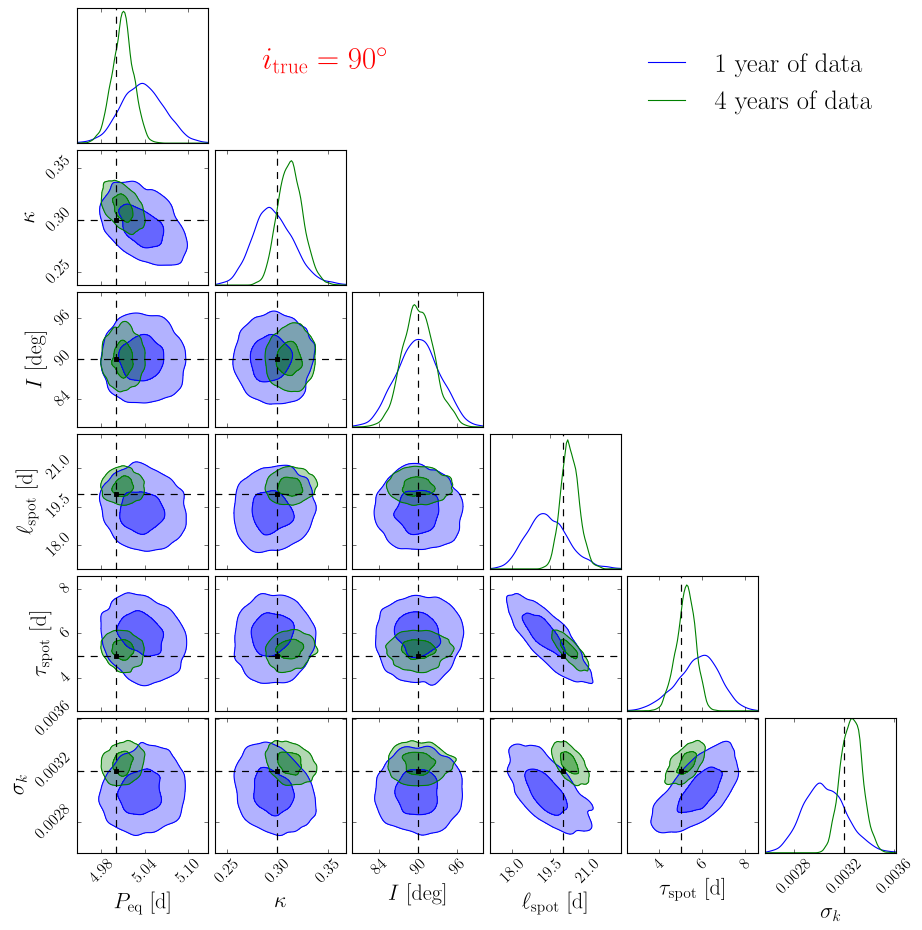

In [47]:
fig = kde_corner([samples1, samples2], labels,
                 truths=[truths1, truths2],
                 names=["1 year of data", "4 years of data"])
plt.text(0.3, 0.85, r"$i_{{\rm true}} = {}^\circ$".format(90), ha="left", va="center", color="r", transform=fig.transFigure, fontsize=28)
plt.savefig("../src/tex/figures/simulated_corner_dynesty_kde_90.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [44]:
results_dir = "../src/data/results_simulated_dynesty_mean"
res1 = np.load(f"{results_dir}/tsim_365.0_tsamp_1.0_inc_30.0_peq_5.0/dynesty_results.npz", allow_pickle=True)
res2 = np.load(f"{results_dir}/tsim_1460.0_tsamp_1.0_inc_30.0_peq_5.0/dynesty_results.npz", allow_pickle=True)

samples1 = res1["samples"]
samples2 = res2["samples"]
samples1.T[2] = np.rad2deg(samples1.T[2])
samples2.T[2] = np.rad2deg(samples2.T[2])

param_keys = [str(k) for k in res1["param_keys"]]
assert param_keys == [str(k) for k in res2["param_keys"]]
labels = [label_dict[k] for k in param_keys]

truths1, truths2 = get_truths(res1, param_keys), get_truths(res2, param_keys)

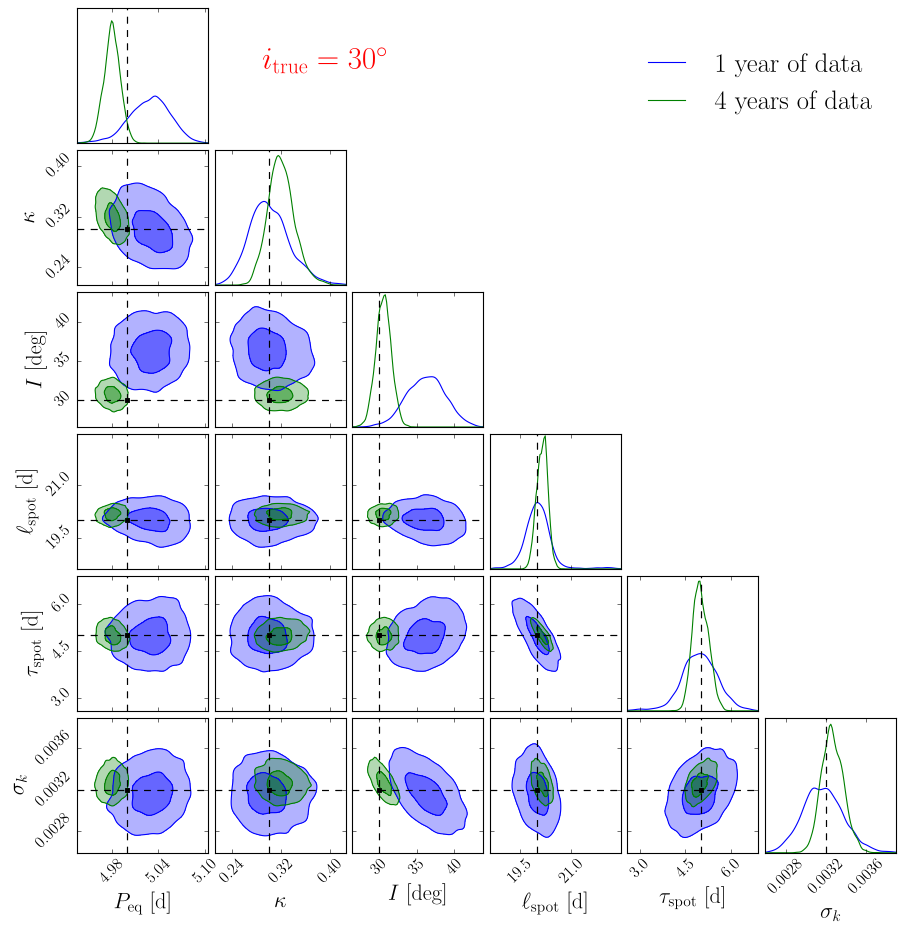

In [45]:
fig = kde_corner([samples1, samples2], labels,
                 truths=[truths1, truths2],
                 names=["1 year of data", "4 years of data"])
plt.text(0.3, 0.85, r"$i_{{\rm true}} = {}^\circ$".format(30), ha="left", va="center", color="r", transform=fig.transFigure, fontsize=28)
plt.savefig("../src/tex/figures/simulated_corner_dynesty_kde_30.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [54]:
list(res1.keys())

['samples', 'logz', 'logzerr', 'param_keys', 'true_params', 'elapsed']

In [62]:
TSIM = 365.0
inc_deg = 90.0
true_params = {
    "peq":      5.0,
    "kappa":    0.3,
    "inc":      np.deg2rad(inc_deg),
    "lspot":    20.0,
    "tau_spot": 5.0,
    "nspot_rate": 0.25,
    "fspot":      0,
    "alpha_max":  0.08,
}

results_dir = "../src/data/results_simulated_dynesty_mean"
subdir = f"tsim_{TSIM}_tsamp_1.0_inc_{inc_deg}_peq_{true_params['peq']}"
res = np.load(f"{results_dir}/{subdir}/dynesty_results.npz", allow_pickle=True)
sim_data = np.load(f"{results_dir}/{subdir}/simulated_data.npz", allow_pickle=True)

samples = res["samples"]
samples.T[2] = np.rad2deg(samples.T[2])

envelope = TrapezoidSymmetricEnvelope(lspot=true_params["lspot"], tau_spot=true_params["tau_spot"])
visibility = VisibilityFunction(peq=true_params["peq"], kappa=true_params["kappa"],
                                inc=true_params["inc"])
model = SpotEvolutionModel(envelope=envelope,
                                visibility=visibility,
                                nspot_rate=true_params["nspot_rate"],
                                fspot=true_params["fspot"],
                                alpha_max=true_params["alpha_max"])

bounds = {
    "peq":      (0.9 * true_params["peq"], 1.1 * true_params["peq"]),
    "kappa":    (-1.0, 1.0),
    "inc":      (true_params["inc"] - np.pi/6, true_params["inc"] + np.pi/6),
    "lspot":    (10.0, 30.0),
    "tau_spot": (0.0, 10.0),
    "sigma_k":  (1e-3, 1e-2),
}

ts = TimeSeriesData(x=sim_data["time"], y=sim_data["flux_obs"], yerr=sim_data["yerr"], normalize=False)
ak = AnalyticKernel(model, n_harmonics=(0,1,2,3)).build_jax()
gp = GPSolver(ts, model, bounds).build_jax()

In [ ]:
gp.compute_acf()

In [3]:
def kernel_posterior(tsim, inc_deg, n_draw=2000, seed=0, tsamp=1.0, peq=5.0,
                     results_dir="../src/data/results_simulated_dynesty_mean",
                     tlags_kernel=np.linspace(0, 40, 401),
                     tlags_psd=np.arange(0, 200, 0.1)):
    """Kernel and PSD evaluated at the truth and at random posterior draws."""
    subdir = f"{results_dir}/tsim_{tsim}_tsamp_{tsamp}_inc_{inc_deg}_peq_{peq}"
    res = np.load(f"{subdir}/dynesty_results.npz", allow_pickle=True)
    sim = np.load(f"{subdir}/simulated_data.npz", allow_pickle=True)
    tp = res["true_params"].item()

    # rebuild the GP as mcmc_simulated_dynesty.py fit it
    model = SpotEvolutionModel(
        envelope=TrapezoidSymmetricEnvelope(lspot=tp["lspot"], tau_spot=tp["tau_spot"]),
        visibility=VisibilityFunction(peq=tp["peq"], kappa=tp["kappa"], inc=tp["inc"]),
        nspot_rate=tp["nspot_rate"], fspot=tp["fspot"], alpha_max=tp["alpha_max"])
    bounds = {
        "peq":      (0.9 * tp["peq"], 1.1 * tp["peq"]),
        "kappa":    (-1.0, 1.0),
        "inc":      (tp["inc"] - np.pi/6, tp["inc"] + np.pi/6),
        "lspot":    (10.0, 30.0),
        "tau_spot": (0.0, 10.0),
        "sigma_k":  (1e-3, 1e-2),
    }
    flux = sim["flux_obs"] - np.mean(sim["flux_obs"])
    ts = TimeSeriesData(x=sim["time"], y=flux, yerr=sim["yerr"], normalize=False)
    gp = GPSolver(ts, model, bounds)
    assert list(gp.param_keys) == [str(k) for k in res["param_keys"]]

    # dynesty samples are equally weighted; res["samples"] re-reads the file,
    # so inc is still in radians here
    samples = res["samples"]
    idx = np.random.default_rng(seed).choice(len(samples), min(n_draw, len(samples)), replace=False)
    truth = [tp[k] for k in gp.param_keys]
    theta = np.vstack([truth, samples[idx]])

    tau, K = gp.compute_kernel_samples(theta, tlags=tlags_kernel)
    freq, P = gp.compute_kernel_samples(theta, kind="psd", tlags=tlags_psd)
    return dict(tau=tau, K_true=K[0], K=K[1:], freq=freq, P_true=P[0], P=P[1:])

In [4]:
post = {(inc, tsim): kernel_posterior(tsim, inc)
        for inc in (90.0, 30.0) for tsim in (365.0, 1460.0)}

In [5]:
def plot_band(ax, x, Y, color, label=None):
    """Posterior median with pointwise 68% and 95% intervals."""
    lo2, lo1, med, hi1, hi2 = np.percentile(Y, [2.5, 16, 50, 84, 97.5], axis=0)
    ax.fill_between(x, lo2, hi2, color=color, alpha=0.15, lw=0)
    ax.fill_between(x, lo1, hi1, color=color, alpha=0.35, lw=0)
    ax.plot(x, med, color=color, lw=1.5, label=label)

names = {365.0: "1 year of data", 1460.0: "4 years of data"}
f_nyq = 0.5 / 1.0  # data Nyquist frequency for tsamp = 1 d

def plot_kernel_psd_posterior(inc):
    """K(tau)/K(0) (left) and PSD (right), with residuals from the truth below."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex="col",
                             gridspec_kw=dict(height_ratios=[3, 1], hspace=0.05, wspace=0.25))
    (ax_k, ax_p), (ax_kr, ax_pr) = axes
    for tsim, color in zip((365.0, 1460.0), ("C0", "C1")):
        p = post[(inc, tsim)]
        acf = p["K"] / p["K"][:, :1]  # each draw normalized by its own K(0)
        acf_true = p["K_true"] / p["K_true"][0]
        plot_band(ax_k, p["tau"], acf, color, names[tsim])
        plot_band(ax_kr, p["tau"], acf - acf_true, color)
        plot_band(ax_p, p["freq"], p["P"], color, names[tsim])
        plot_band(ax_pr, p["freq"], p["P"] / p["P_true"] - 1, color)
    # both baselines are simulated from the same true parameters
    ax_k.plot(p["tau"], acf_true, "k--", lw=1.5, label="True")
    ax_p.plot(p["freq"], p["P_true"], "k--", lw=1.5, label="True")
    for ax in (ax_kr, ax_pr):
        ax.axhline(0, color="k", ls="--", lw=1.5)

    ax_kr.set_xlim(0, p["tau"][-1])
    ax_pr.set_xlim(0, f_nyq)
    ax_p.set_yscale("log")
    ax_p.set_ylim(1e-5 * p["P_true"].max(), 3 * p["P_true"].max())
    # the fractional residual spikes where P_true -> 0 at the PSD nulls
    ax_pr.set_ylim(-1, 1)
    ax_k.set_ylabel(r"$K(\tau)/K(0)$", fontsize=20)
    ax_p.set_ylabel("PSD", fontsize=20)
    ax_kr.set_ylabel(r"$\Delta\,K/K(0)$", fontsize=20)
    ax_pr.set_ylabel(r"$P/P_{\rm true} - 1$", fontsize=20)
    ax_kr.set_xlabel(r"$\tau$ [d]", fontsize=20)
    ax_pr.set_xlabel(r"Frequency [d$^{-1}$]", fontsize=20)
    for ax in axes.ravel():
        ax.tick_params(labelsize=14)
    for ax in (ax_kr, ax_pr):
        ax.yaxis.set_major_locator(MaxNLocator(3, symmetric=True))
    ax_k.legend(fontsize=16, frameon=False)
    fig.suptitle(rf"$i_{{\rm true}} = {inc:.0f}^\circ$", fontsize=24, y=0.96)
    return fig

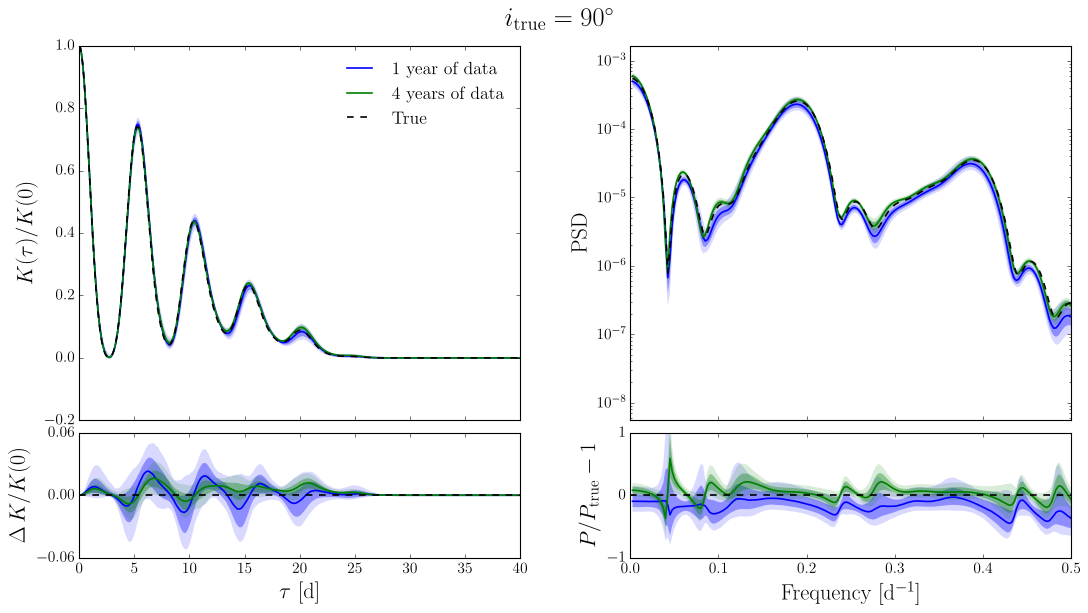

In [6]:
fig = plot_kernel_psd_posterior(90.0)
plt.savefig("../src/tex/figures/simulated_kernel_psd_posterior_90.pdf", bbox_inches="tight", dpi=300)
plt.show()

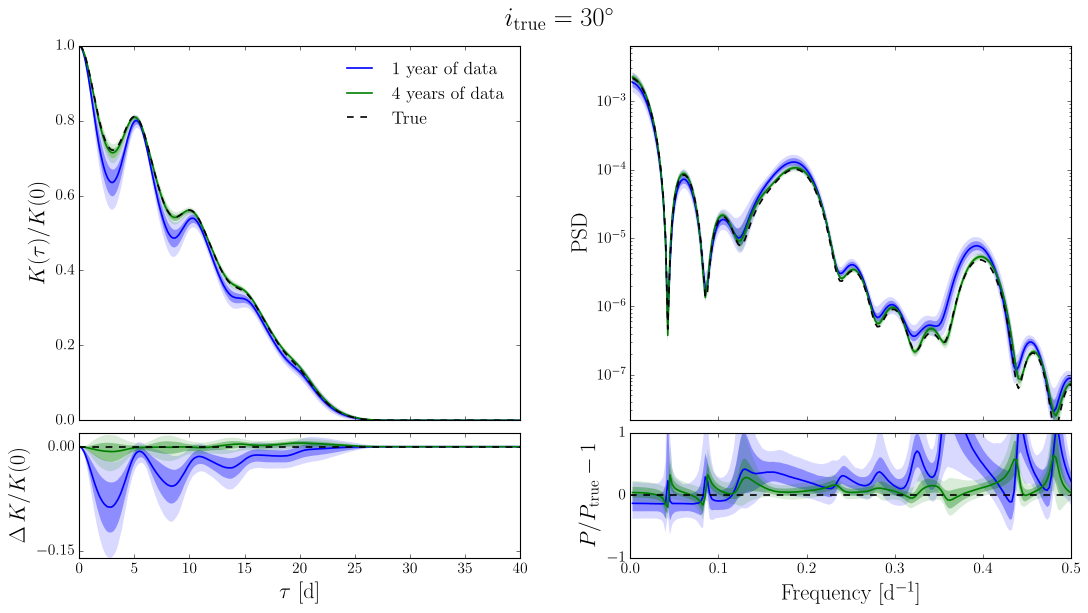

In [7]:
fig = plot_kernel_psd_posterior(30.0)
plt.savefig("../src/tex/figures/simulated_kernel_psd_posterior_30.pdf", bbox_inches="tight", dpi=300)
plt.show()